# Nhận diện một cuộc tấn công thông qua mô hình Logistic Regression

Ở notebook trước (`01-training-model-lr.ipynb`), việc so sánh mô hình sạch và mô hình bị tấn công dựa trên thông tin đã biết trước: ta biết chính xác tập nào là `"0"` (sạch) và tập nào là `"45"` (bị đầu độc 45%), nên có thể so sánh trực tiếp accuracy và loss giữa hai kịch bản.

Trong thực tế, một hệ thống phòng thủ không biết trước liệu dữ liệu huấn luyện có bị đầu độc hay không, và đầu độc ở mức bao nhiêu phần trăm. Notebook này đi tìm các dấu hiệu gián tiếp (indirect signal) — những đại lượng có thể quan sát được mà không cần biết nhãn thật đã bị đảo ở đâu — để "nhận biết" (awareness) rằng mô hình đang được huấn luyện trên dữ liệu khả nghi. Đây là bước tiền đề cho phần phòng thủ (`src/defend`) sau này: muốn phòng thủ, trước tiên phải phát hiện được có tấn công.

Bốn case dưới đây khảo sát 4 loại dấu hiệu khác nhau, phần lớn quan sát theo % tỉ lệ nhãn bị đảo (flip) từ 0% đến 45%, dùng các mô hình đã huấn luyện sẵn ở `src/models` (`lr_trained, dt_trained` — mỗi model được train riêng cho từng mức % flip).

In [1]:
import sys, os 
from pathlib import Path

project_root = Path.cwd().parent 

os.chdir(project_root)
sys.path.append(str(project_root))

In [2]:
# Python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Project
from src.preprocess import X_test, y_test, train_dfs
from src.utils.math import *

## Chuẩn bị

Chuẩn bị dữ liệu và tham số dùng chung cho toàn bộ notebook:

In [3]:
# Const
C_val = 0.01
epochs = 1000

# Scalling
sc = StandardScaler().fit(train_dfs[0]["X"])
X_test_scaled = sc.transform(X_test)            # Because X on poisoned data is the same, so we only need to scale once

## 1. Trường hợp 1 - Khoảng cách giữa `train_loss` và `val_loss`

Ý tưởng: ở notebook trước, ta đã quan sát rằng mô hình huấn luyện trên dữ liệu sạch có train loss và test (val) loss bám khá sát nhau, trong khi mô hình huấn luyện trên dữ liệu bị đầu độc có khoảng cách (gap) lớn hơn. Case này đo trực tiếp đại lượng `gap = val_loss - train_loss` qua từng epoch, xem nó biến đổi thế nào khi huấn luyện trên tập bị đầu độc 45%.

### 1.1. Chuẩn bị

#### 1.1.1. Training trên Dữ liệu sạch

Khởi tạo `w_cleaned = [0.0, ..., 0.0]`, `b_cleaned = 0`, huấn luyện gradient descent trên `X_train_cleaned`/`y_train_cleaned` (tập "0"), nhưng ở mỗi epoch tính thêm:

- `train_loss`: loss trên chính tập train (bị đầu độc).
- `val_loss`: loss trên tập test sạch.
- `gap = val_loss - train_loss`, lưu lại vào danh sách `gap_cleaned` để vẽ đồ thị.

In [4]:
w_cleaned = np.zeros(X_test.shape[1])
b_cleaned = 0

data_train_cleaned = train_dfs[0]
X_train_cleaned, y_train_cleaned = data_train_cleaned["X"], data_train_cleaned["attack"]

# Scalling data
sc_cleaned = StandardScaler()
X_train_cleaned = sc_cleaned.fit_transform(X_train_cleaned)

gap_cleaned = []

for epoch in range(epochs + 1):
    train_loss = loss(y_train_cleaned, sigmoid(X_train_cleaned @ w_cleaned + b_cleaned))
    val_loss = loss(y_test, sigmoid(X_test_scaled @ w_cleaned + b_cleaned))

    gap_cleaned.append(val_loss - train_loss)

    dw, db = gradient(X_train_cleaned, y_train_cleaned, sigmoid(X_train_cleaned @ w_cleaned + b_cleaned))

    w_cleaned -= C_val * dw
    b_cleaned -= C_val * db

/home/khoi/workspace/label-flipping-project/src/utils/math.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


#### 1.1.2. Training trên Dữ liệu độc

Tương tự như ở `1.1.1`, ta thực hiện training model trên dữ liệu bị đầu độc mức **45%** và lưu vào `gap_poisoned`.

In [5]:
w_poisoned = np.zeros(X_test.shape[1])
b_poisoned = 0

data_train_poisoned = train_dfs[45]
X_train_poisoned, y_train_poisoned = data_train_poisoned["X"], data_train_poisoned["attack"]

# Scalling data
sc_poisoned = StandardScaler()
X_train_poisoned = sc_poisoned.fit_transform(X_train_poisoned)

gap_poisoned = []

for epoch in range(epochs + 1):
    train_loss = loss(y_train_poisoned, sigmoid(X_train_poisoned @ w_poisoned + b_poisoned))
    val_loss = loss(y_test, sigmoid(X_test_scaled @ w_poisoned + b_poisoned))

    gap_poisoned.append(val_loss - train_loss)

    dw, db = gradient(X_train_poisoned, y_train_poisoned, sigmoid(X_train_poisoned @ w_poisoned + b_poisoned))

    w_poisoned -= C_val * dw
    b_poisoned -= C_val * db

/home/khoi/workspace/label-flipping-project/src/utils/math.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


### 1.2. Vẽ biểu đồ

#### 1.2.1. Cleaning

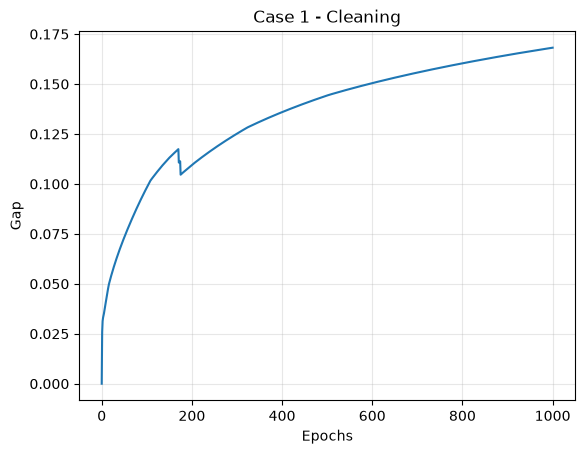

In [6]:
plt.plot(gap_cleaned)
plt.xlabel("Epochs")
plt.ylabel("Gap")
plt.title("Case 1 - Cleaning")
plt.grid(True, alpha=0.3)
plt.show()

#### 1.2.2. Poisoning

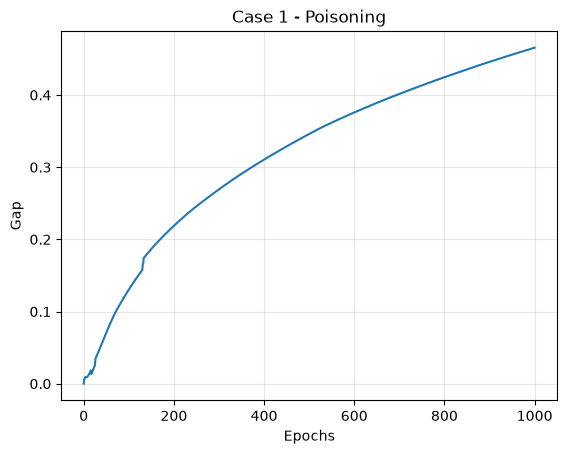

In [7]:
plt.plot(gap_poisoned)
plt.xlabel("Epochs")
plt.ylabel("Gap")
plt.title("Case 1 - Poisoning")
plt.grid(True, alpha=0.3)
plt.show()

### 1.3. Kết luận

**Kết quả quan sát được:** ở tập bị đầu độc 45%, `gap` **tăng đơn điệu** theo epoch — từ gần 0 lúc mới khởi tạo, tăng dần lên đến khoảng **0.46** ở epoch 1000, không có dấu hiệu chững lại hay giảm xuống. Ở tập sạch (0%), `gap` cũng tăng dần theo epoch nhưng dừng lại ở mức thấp hơn nhiều — khoảng **0.17** ở epoch 1000 (xem đồ thị "Case 1 - Cleaning" ở trên) — tức là gap của mô hình đầu độc lớn hơn khoảng **2.7 lần** so với mô hình sạch tại cùng epoch.

Lưu ý: cả hai đường đều chưa thực sự "bão hòa" hẳn ở epoch 1000 (cả hai còn hơi đi lên), nên điểm phân biệt rõ ràng nhất giữa hai kịch bản không phải là "tăng liên tục vs. hội tụ", mà là **biên độ (magnitude)** và **tốc độ tăng** của gap: mô hình huấn luyện trên dữ liệu đầu độc có gap lớn hơn nhiều lần và tăng nhanh hơn rõ rệt so với mô hình sạch, dù cả hai cùng huấn luyện trong 1000 epoch với cùng learning rate. Cả hai đồ thị cũng có một điểm gãy nhỏ (~epoch 130–170) — nhiều khả năng liên quan đến cảnh báo `RuntimeWarning: overflow encountered in exp` ghi nhận trong log chạy của cell huấn luyện, tức là hàm `sigmoid` bị tràn số ở một vài epoch đầu; điều này không làm thay đổi kết luận chính nhưng đáng lưu ý nếu muốn dùng gap tuyệt đối làm ngưỡng cảnh báo.

→ **Dấu hiệu awareness #1:** nếu quan sát thấy gap giữa train loss và validation loss tăng nhanh và đạt biên độ lớn bất thường (so với baseline huấn luyện trên dữ liệu tin cậy) qua nhiều epoch — đó là tín hiệu cảnh báo dữ liệu huấn luyện có thể đã bị nhiễm/đầu độc, ngay cả khi không biết trước nhãn nào bị sai.

## 2. Trường hợp 2 - Kiểm tra trọng số `norm`

**Ý tưởng:** khi mô hình bị buộc phải "giải thích" cho các nhãn mâu thuẫn nhau (một phần nhãn đúng, một phần bị đảo), nó thường phải đẩy trọng số lên cao hơn để cố gắng phân tách các điểm dữ liệu — vốn dĩ đang lẫn lộn tín hiệu — thành hai lớp. Case này đo độ lớn `||w||` (chuẩn Euclid của vector trọng số) của các mô hình `lr_trained` đã huấn luyện sẵn ở nhiều mức % flip khác nhau.

### 2.1. Chuẩn bị

Lấy toàn bộ mô hình Logistic Regression đã huấn luyện sẵn trong `src.models.lr_trained` (dict key là % flip dạng string), sắp xếp theo thứ tự % flip tăng dần, rồi tính `np.linalg.norm(model.coef_)` cho từng mô hình.

In [8]:
from src.models import lr_trained

w_nomrs = []
flip_percent = []

for percent, model in sorted(lr_trained.items()):
    w_nomrs.append(np.linalg.norm(model.coef_))
    flip_percent.append(percent)

### 2.2. Vẽ biểu đồ

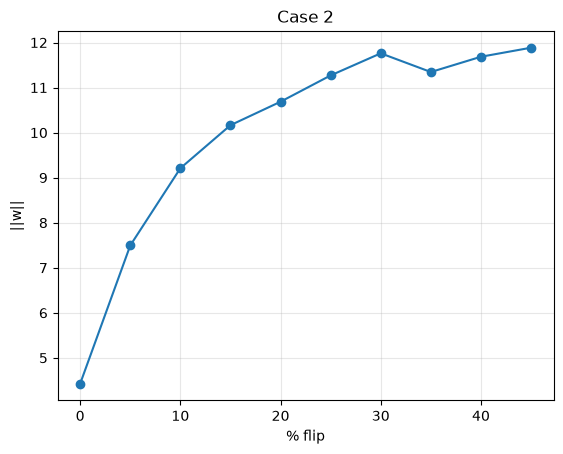

In [9]:
plt.plot(flip_percent, w_nomrs, marker="o")
plt.xlabel("% flip")
plt.ylabel("||w||")
plt.title("Case 2")
plt.grid(True, alpha=0.3)
plt.show()

### 2.3. Kết luận

**Kết quả quan sát được:** `||w||` tăng nhanh ở mức flip thấp — từ **≈ 4.4** (0% flip) lên **≈ 9.2** (10% flip) chỉ trong 10 điểm % đầu — sau đó tăng chậm dần, đạt một đỉnh tạm **≈ 11.8** ở **30%**, giảm nhẹ xuống **≈ 11.35** ở **35%**, rồi tăng lại và đạt mức cao nhất trong toàn bộ dãy **≈ 11.9** ở **45%**. Nhìn tổng thể đây là một đường cong dạng bão hòa (tăng nhanh rồi dao động nhẹ quanh 11–12), không phải một đường thẳng tuyến tính, và không hoàn toàn đơn điệu ở phần đuôi.

Xu hướng tăng chung này khớp với giả thuyết ban đầu: càng nhiều nhãn bị đảo, mô hình càng phải "cố" tăng độ dốc quyết định (trọng số lớn hơn) để cố gắng phân tách dữ liệu, dù bản chất dữ liệu đã bị nhiễu và không còn khả năng phân tách rạch ròi như ban đầu. Tuy vậy, cần lưu ý là **cả 10 mô hình `lr_trained` ở mọi mức % flip (kể cả mô hình 0% "sạch") đều phát sinh `ConvergenceWarning` do solver `lbfgs` không hội tụ trong 100 iteration** (xem log ở cell trên) — nghĩa là cú giảm nhẹ ở 35% và việc không tăng đơn điệu tuyệt đối ở phần đuôi (30–45%) nhiều khả năng đến từ việc optimizer dừng sớm giữa chừng ở một vài điểm %, chứ không hẳn chỉ do bản chất dữ liệu nhiễu ở mức cao. Nên coi phần dao động ở 30–45% là một quan sát cần thêm dữ liệu (ví dụ tăng `max_iter`) để xác nhận, hơn là một kết luận chắc chắn.

→ **Dấu hiệu awareness #2:** `||w||` bất thường lớn so với baseline (mô hình huấn luyện trên dữ liệu tin cậy) là tín hiệu cho thấy mô hình có thể đang bị buộc khớp với nhãn nhiễu — có thể dùng làm một dạng "anomaly threshold" để cảnh báo, miễn là baseline được huấn luyện với cùng điều kiện hội tụ (cùng `max_iter`) để tránh nhiễu do optimizer chưa hội tụ.

## 3. Trường hợp 3 - So sánh với một mô hình khác (Decision Tree)

**Ý tưởng:** nếu huấn luyện hai loại mô hình khác nhau (ở đây là Logistic Regression — mô hình tuyến tính, và Decision Tree — mô hình phi tuyến) trên cùng một tập dữ liệu, và dữ liệu đó sạch, hai mô hình thường sẽ đồng thuận (dự đoán giống nhau) trên phần lớn các mẫu, vì cả hai đều đang học cùng một quy luật thật. Nếu dữ liệu bị đầu độc, các mô hình có kiến trúc khác nhau sẽ phản ứng khác nhau với nhiễu, khiến tỉ lệ bất đồng (disagreement) giữa chúng tăng lên.

### 3.1. Chuẩn bị

Với mỗi mức % flip, lấy cặp mô hình `lr_model` (`lr_trained`) và `dt_model` (`dt_trained`) đã huấn luyện sẵn cùng mức đó, dự đoán trên cùng `X_test`, rồi tính `disagreement_rate = np.mean(y_lr_pred != y_dt_pred)` — tỉ lệ phần trăm mẫu mà hai mô hình đưa ra dự đoán khác nhau.

In [10]:
from src.models import dt_trained

disagreement_rates = []

for percent in flip_percent:
    lr_model = lr_trained[percent]
    dt_model = dt_trained[percent]

    y_lr_pred = lr_model.predict(X_test_scaled)
    y_dt_pred = dt_model.predict(X_test_scaled)

    disagreement_rates.append(np.mean(y_lr_pred != y_dt_pred))

### 3.2. Vẽ biểu đồ

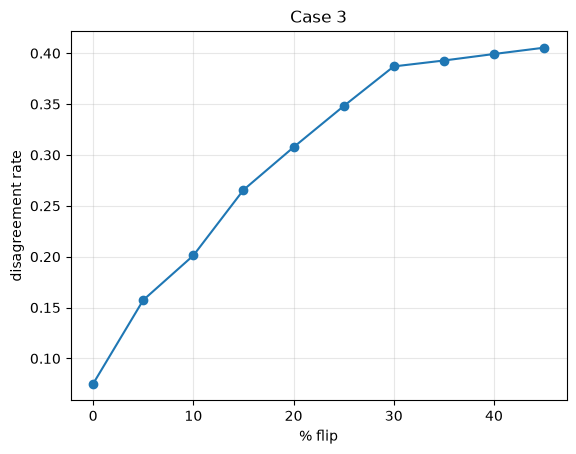

In [11]:
plt.plot(flip_percent, disagreement_rates, marker="o")
plt.xlabel("% flip")
plt.ylabel("disagreement rate")
plt.title("Case 3")
plt.grid(True, alpha=0.3)
plt.show()

### 3.3. Kết luận

**Kết quả quan sát được:** disagreement rate tăng đều từ **≈ 8%** (0% flip) lên đến **≈ 41%** (45% flip) — tăng hơn 5 lần.
 
Ở mức 0% flip, hai mô hình khác kiến trúc vẫn đồng thuận đến 92% số mẫu — hợp lý vì cả hai đều học đúng ranh giới quyết định thật. Nhưng khi tỉ lệ flip tăng, LR (mô hình tuyến tính, nhạy với nhiễu nhãn vì tối ưu toàn cục theo trung bình gradient) và DT (mô hình phi tuyến, có xu hướng "chia nhỏ" không gian để khớp cả điểm nhiễu cục bộ) phản ứng khác nhau trước cùng một tập nhãn bị nhiễu, khiến chúng ngày càng bất đồng.
 
→ **Dấu hiệu awareness #3:** huấn luyện song song 2 mô hình có "thiên kiến quy nạp" (inductive bias) khác nhau trên cùng một dữ liệu, rồi đo tỉ lệ bất đồng, là một kỹ thuật phát hiện dữ liệu khả nghi phổ biến trong thực tế (không cần biết nhãn thật) — disagreement rate cao bất thường so với baseline là dấu hiệu cảnh báo.

## 4. Trường hợp 4 - Kiểm tra `accuracy` của model

**Ý tưởng:** đây là phép đo trực tiếp và trực quan nhất — khác với 3 case trên (vốn không cần biết nhãn thật của quá trình tấn công), case này giả định ta *có* một tập test đáng tin cậy để đo accuracy thật của từng mô hình `lr_trained` qua các mức % flip, dùng làm đường cong tham chiếu ("ground truth") để đối chiếu lại với các dấu hiệu gián tiếp ở Case 1–3.

### 4.1. Chuẩn bị

Với mỗi mức % flip, lấy `model = lr_trained[str(percent)]`, dự đoán trên `X_test` (đã scale), tính `accuracy_score(y_test, model.predict(X_test_scaled))`, lưu vào `acc_history`.

Ngoài ra, code cũng tính thêm `extreme_ratio`: tỉ lệ dự đoán "quá tự tin" — xác suất `< 0.05` hoặc `> 0.95` — và lưu vào `extreme_ratio_history` để vẽ chung với accuracy ở đồ thị bên dưới. Đây là một dấu hiệu awareness bổ sung: giả thuyết ban đầu là mô hình bị ép khớp dữ liệu nhiễu sẽ đưa ra dự đoán cực đoan hơn để "cố phân tách" các điểm mâu thuẫn — kết quả thực tế ở mục 4.3 cho thấy điều ngược lại, xem phần kết luận.

In [12]:
acc_history = []
extreme_ratio_history = []

for percent in flip_percent:
    model = lr_trained[percent]
    probs = model.predict_proba(X_test_scaled)[:, 1]

    extreme_ratio = np.mean((probs < 0.05) | (probs > 0.95))
    extreme_ratio_history.append(extreme_ratio)

    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    acc_history.append(acc)

### 4.2. Vẽ biểu đồ

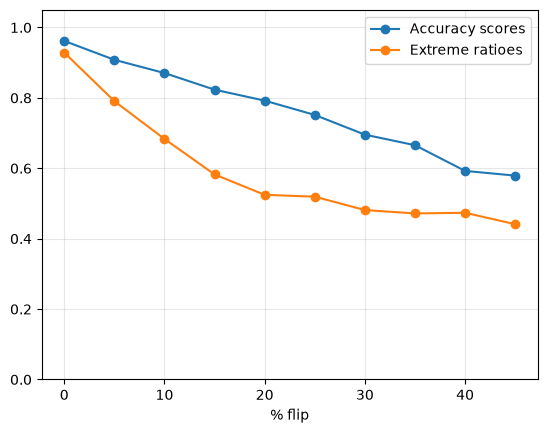

In [13]:
plt.plot(flip_percent, acc_history, marker="o", label="Accuracy scores")
plt.plot(flip_percent, extreme_ratio_history, marker="o", label="Extreme ratioes")

plt.xlabel("% flip")
plt.ylabel("")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

plt.legend()
plt.show()

### 4.3. Kết luận

**Kết quả quan sát được (Accuracy):** accuracy giảm gần như tuyến tính từ **≈ 96%** (0% flip, khớp với kết quả 96.44% ở notebook `01-training-model-lr.ipynb`) xuống còn **≈ 58%** ở 45% flip — gần chạm mức đoán ngẫu nhiên với bài toán nhị phân.

**Kết quả quan sát được (Extreme ratio):** ngược lại với giả thuyết nêu ở mục 4.1, `extreme_ratio` **giảm** dần theo % flip — từ **≈ 0.93** (0% flip) xuống còn **≈ 0.45** (45% flip), gần như đi song song và cùng xu hướng giảm với accuracy chứ không tăng lên. Điều này thực ra hợp lý hơn giả thuyết ban đầu: khi nhãn trong tập train ngày càng mâu thuẫn nhau, mô hình logistic regression (tối ưu theo trung bình gradient trên toàn bộ dữ liệu) không "chọn phe" cực đoan cho từng điểm nhiễu, mà có xu hướng đưa xác suất dự đoán về gần 0.5 hơn — tức là *kém tự tin hơn*, không phải tự tin sai một cách cực đoan.

Đường cong accuracy xác nhận rằng cả 3 dấu hiệu gián tiếp ở Case 1–3 (gap loss tăng, `||w||` tăng, disagreement rate tăng) đều **tương quan cùng chiều** với mức độ suy giảm accuracy thật — nghĩa là các dấu hiệu đó là những "proxy" hợp lý để nhận biết tấn công, ngay cả trong tình huống không có tập test đáng tin cậy để đo accuracy trực tiếp như ở đây. Riêng `extreme_ratio` cũng tương quan (nghịch chiều) với accuracy nên vẫn có thể dùng làm proxy bổ sung — chỉ cần diễn giải đúng chiều: **`extreme_ratio` giảm mạnh, chứ không tăng, là dấu hiệu cảnh báo.**

## Kết luận

Bốn thí nghiệm trong notebook này cho thấy tấn công label flipping để lại **nhiều dấu vết quan sát được** trên hành vi của mô hình, không chỉ thể hiện qua con số accuracy cuối cùng:

| Case | Dấu hiệu | Xu hướng khi % flip tăng (0% → 45%) | Cần biết nhãn thật? |
|---|---|---|---|
| 1 | Gap giữa train loss và val loss | Tăng liên tục, biên độ lớn hơn hẳn baseline sạch (~0.17 → ~0.46) | Cần tập val sạch |
| 2 | `\|\|w\|\|` (chuẩn trọng số) | Tăng nhanh rồi dao động nhẹ quanh 11–12 (~4.4 → ~11.9, đỉnh tạm ở 30%, lưu ý chưa hội tụ ổn định) | Không cần |
| 3 | Disagreement rate giữa LR và DT | Tăng mạnh (~8% → ~41%) | Không cần |
| 4 | Accuracy thật trên test sạch | Giảm mạnh (~96% → ~58%) | Cần tập test có nhãn đúng |

*(Bổ sung: `extreme_ratio` — tỉ lệ dự đoán quá tự tin — cũng giảm rõ rệt theo % flip (~93% → ~45%), cùng chiều với accuracy; đây là một tín hiệu phụ không cần nhãn thật, đo được cùng lúc với Case 4.)*

Điểm quan trọng nhất: **Case 2 và Case 3 không cần biết nhãn thật hay tập test sạch** — đây chính là hai dấu hiệu khả thi nhất để triển khai một cơ chế "awareness" thực tế, phát hiện dữ liệu khả nghi *trước khi* mô hình được đưa vào sử dụng, chỉ dựa trên hành vi nội tại của mô hình (độ lớn trọng số) hoặc sự đồng thuận giữa nhiều mô hình khác kiến trúc — mà không đòi hỏi một tập dữ liệu "ground truth" tốn kém để kiểm chứng. Với Case 2, cần thận trọng thêm về ảnh hưởng của việc solver chưa hội tụ (xem mục 2.3) khi dùng `||w||` làm ngưỡng cảnh báo tuyệt đối.

Đây là nền tảng hợp lý cho bước tiếp theo trong `src/defend`: xây dựng một quy tắc cảnh báo tự động (ví dụ: ngưỡng `||w||` hoặc ngưỡng disagreement rate vượt quá baseline bao nhiêu độ lệch chuẩn thì gắn cờ "khả nghi"), thay vì phải chờ đo được accuracy sụt giảm mới biết dữ liệu đã bị tấn công.